In [1]:
# --- 03c_Modeling_XGBoost.ipynb ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import os







In [2]:
# ---------------------------------------------------------
# Step 1: Loading the UNSCALED Data
# ---------------------------------------------------------
train_data = pd.read_csv('../data/processed/train_unscaled.csv')
test_data = pd.read_csv('../data/processed/test_unscaled.csv')

X_train = train_data.drop(columns=['target'])
y_train = train_data['target']

X_test = test_data.drop(columns=['target'])
y_test = test_data['target']

print("--- Step 1: Data Loading Complete ---")

--- Step 1: Data Loading Complete ---


In [3]:
# ---------------------------------------------------------
# Step 2: Handling Imbalance and Model Initialization
# ---------------------------------------------------------
# XGBoost için sınıf dengesizliğini çözme formülü: (Negatif Sınıf Sayısı) / (Pozitif Sınıf Sayısı)
# Yani: Benign(0) / Malignant(1)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Scale Pos Weight (Kanserli vakalara verilecek ekstra önem): {ratio:.2f}")

# XGBoost modelini başlatıyoruz
# n_estimators: Ağaç sayısı
# learning_rate: Modelin hatalardan öğrenme hızı (düşük olması daha sağlam adımlar atmasını sağlar)
xgb_model = xgb.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    scale_pos_weight=ratio, 
    random_state=42,
    eval_metric='logloss' # Uyarı mesajlarını susturmak için
)

# Modeli eğit (Ardışık olarak hatalarından ders alarak öğrenecek)
xgb_model.fit(X_train, y_train)
print("--- Step 2: XGBoost Model Training Complete ---")


Scale Pos Weight (Kanserli vakalara verilecek ekstra önem): 1.29
--- Step 2: XGBoost Model Training Complete ---


In [4]:
# ---------------------------------------------------------
# Step 3: Predictions and Evaluation
# ---------------------------------------------------------
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n--- Step 3: Performance Metrics ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}  --> (Gerçekten kanser olanların yüzde kaçını bulduk?)")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")



--- Step 3: Performance Metrics ---
Accuracy : 0.7705
Recall   : 0.7559  --> (Gerçekten kanser olanların yüzde kaçını bulduk?)
F1-Score : 0.7419
ROC-AUC  : 0.8538


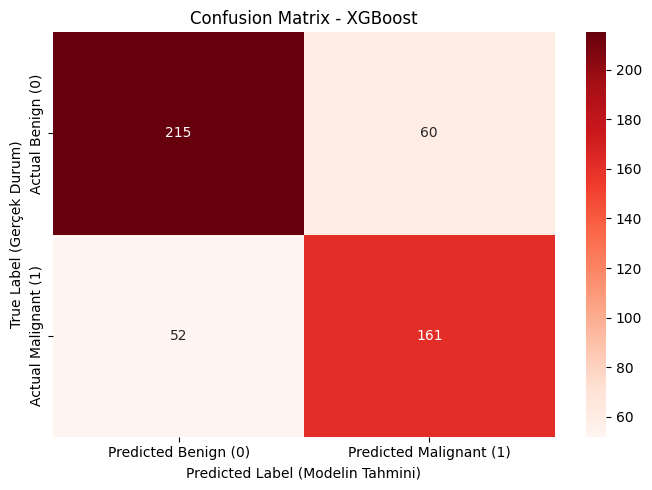

In [5]:
# ---------------------------------------------------------
# Step 4: Visualizing the Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
# Bu sefer kırmızının tonlarını kullanalım
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True Label (Gerçek Durum)')
plt.xlabel('Predicted Label (Modelin Tahmini)')
plt.tight_layout()

# Grafiği kaydet
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/03_XGB_Confusion_Matrix.png', dpi=300)

plt.show()